## Team 
Team Name: Earth's Spiral   
Team Members: Mihir Vad

## Dataset
NASA MODIS (MODerate Resolution Imaging Spectroradiometer) Satellite Imagery  

We are using NASA MODIS land surface temperature data to explore how Earth’s surface temperature anomalies have changed over time. Instead of creating a traditional map-first visualization, our project focuses on turning climate time into a visible shape.

The main aspects of the dataset we plan to use are:

Time: month and year of each observation
Land Surface Temperature: observed surface temperature values
Historical Baseline: average temperature for the same month across a reference period
Temperature Anomaly: difference between observed temperature and historical average
Geographic Context: optional map layer showing where a selected anomaly is concentrated

Our key derived variable is:

Temperature Anomaly = Observed Temperature - Historical Average for Same Month

This lets us focus on when Earth is unusually hot, not just where it is hot.


In [ ]:
import io
import time
import math
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Wedge

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 10

#### helper function to get NASA image given the layer and date

In [12]:
GIBS_WMS_ENDPOINT = "https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi"

LST_LAYER = "MODIS_Terra_Land_Surface_Temp_Day"

GLOBAL_BBOX = (-180, -60, 180, 85)#for latitudes

def fetch_gibs_wms_image(
    layer,
    date,
    bbox=GLOBAL_BBOX,
    width=900,
    height=450,
    image_format="image/png",
    timeout=30
):
    lon_min, lat_min, lon_max, lat_max = bbox

    params = {
        "SERVICE": "WMS",
        "REQUEST": "GetMap",
        "VERSION": "1.1.1",
        "LAYERS": layer,
        "STYLES": "",
        "FORMAT": image_format,
        "TRANSPARENT": "TRUE",
        "SRS": "EPSG:4326",
        "BBOX": f"{lon_min},{lat_min},{lon_max},{lat_max}",
        "WIDTH": width,
        "HEIGHT": height,
        "TIME": date,
    }

    response = requests.get(GIBS_WMS_ENDPOINT, params=params, timeout=timeout)
    response.raise_for_status()

    content_type = response.headers.get("Content-Type", "")
    return Image.open(io.BytesIO(response.content)).convert("RGBA")

def image_to_rgb_array(img):
    arr = np.asarray(img).astype(float) / 255.0
    return arr[:, :, :3]

def show_gibs_image(img, title):
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

#### getting images for specific dates for EDA

In [15]:
dates = [
    "2001-07-15",
    "2005-07-15",
    "2010-07-15",
    "2015-07-15",
    "2020-07-15",
    "2024-07-15",
]

LAYER_TO_USE = LST_LAYER

images = {}

for date in dates:
    start = time.time()
    img = fetch_gibs_wms_image(
        layer=LAYER_TO_USE,
        date=date,
        bbox=GLOBAL_BBOX,
        width=900,
        height=450,
        image_format="image/png"
        )
    images[date] = img

## Graph 1: exploring a basic nasa image

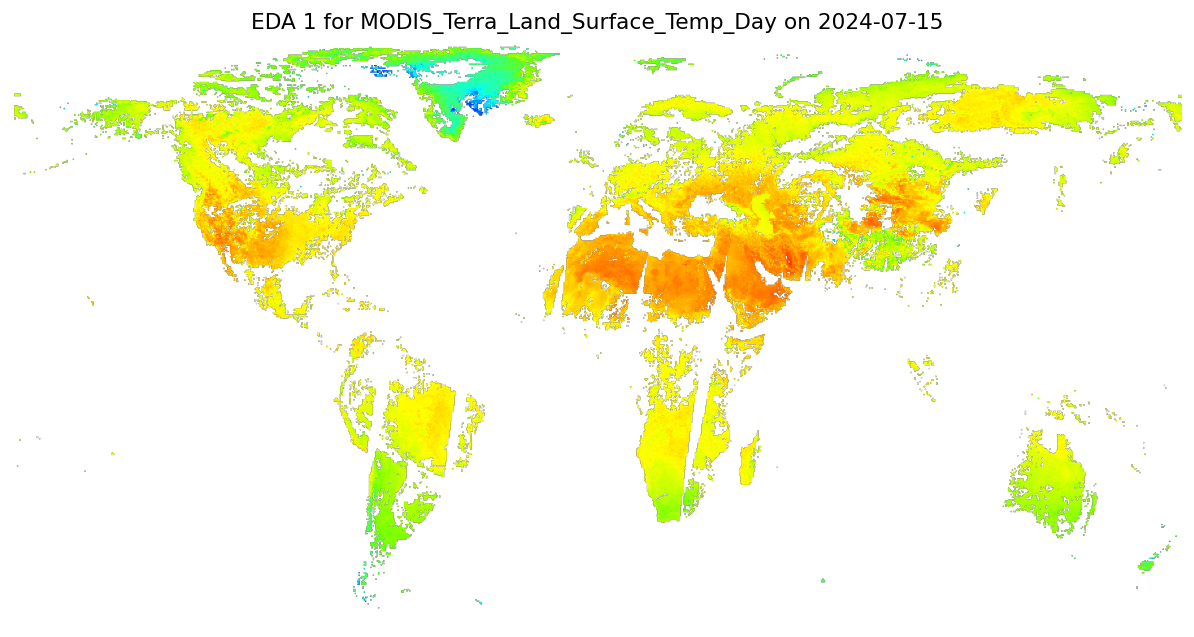

In [17]:
snapshot_date = sorted(images.keys())[-1]
show_gibs_image(images[snapshot_date], f"EDA 1 for {LAYER_TO_USE} on {snapshot_date}")

## Graph 2 - layer across years for time comps

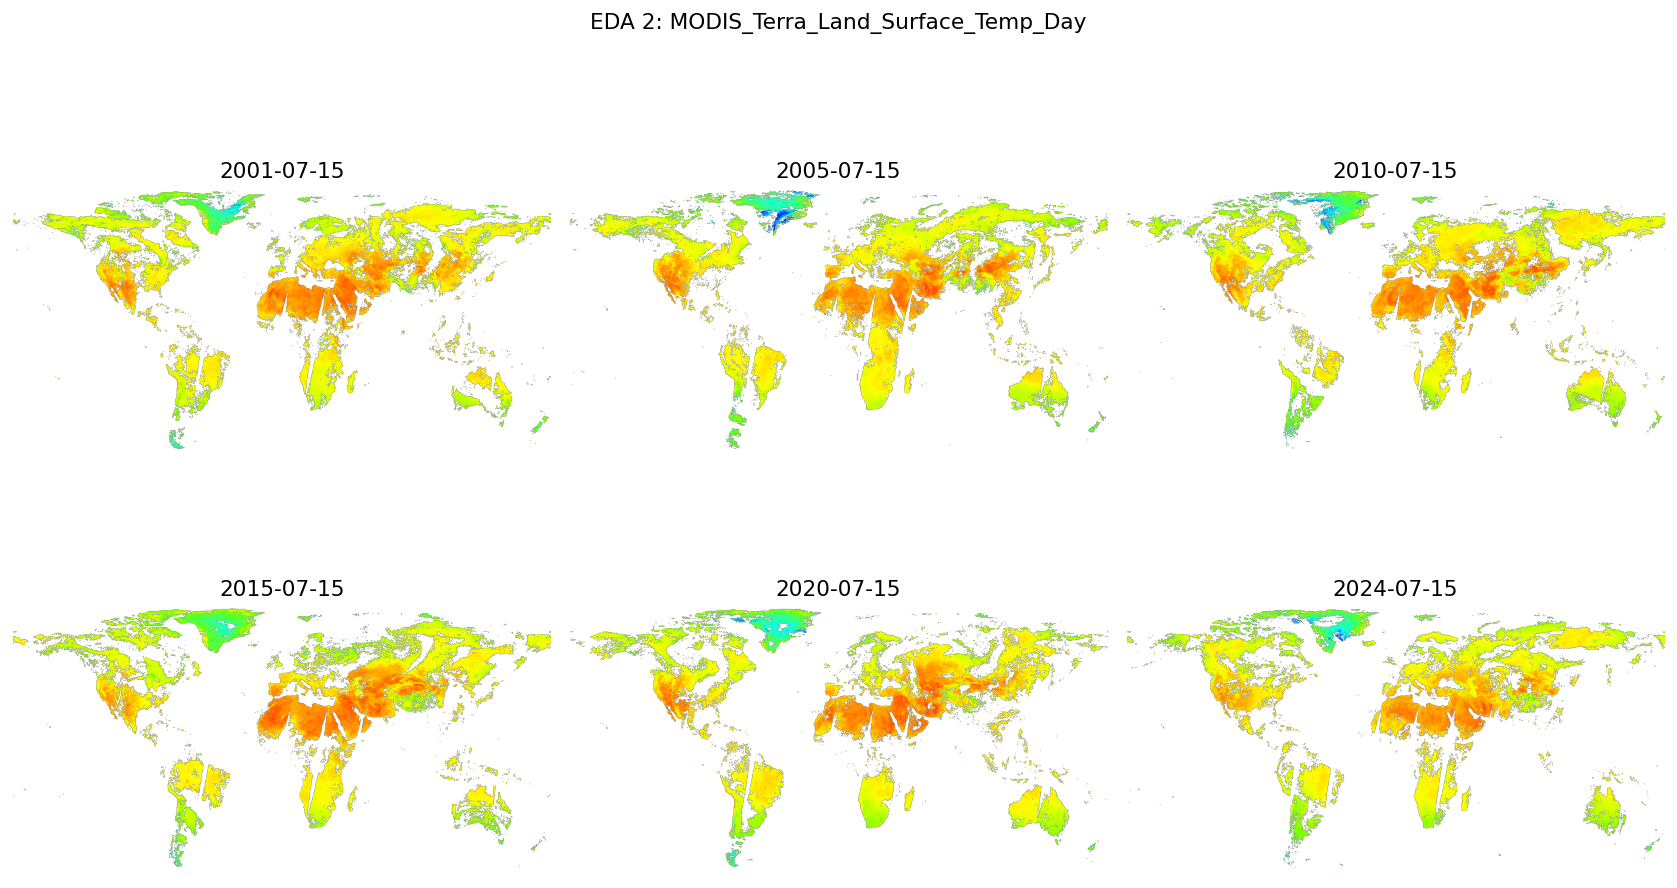

In [20]:
available_dates = sorted(images.keys())

cols = 3
rows = math.ceil(len(available_dates) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(13, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, date in zip(axes, available_dates):
    ax.imshow(images[date])
    ax.set_title(date)
    ax.axis("off")

for ax in axes[len(available_dates):]:
    ax.axis("off")

fig.suptitle(f"EDA 2: {LAYER_TO_USE}")
plt.tight_layout()
plt.show()

# pixel saturity

- mean_red: average red channel intensity
- mean_green: average green channel intensity
- mean_blue: average blue channel intensity
- brightness: average of red, green, and blue
- warm_pixel_ratio: fraction of pixels where red is stronger than blue,green

warm colors often correspond to higher visual intensity.

In [22]:
metrics = []

for date, img in images.items():
    arr = image_to_rgb_array(img)
    red = arr[:, :, 0]
    green = arr[:, :, 1]
    blue = arr[:, :, 2]
    brightness = arr.mean(axis=2)

    warm_mask = (red > blue + 0.08) & (red > green + 0.02)

    metrics.append({
        "date": date,
        "year": int(date[:4]),
        "mean_red": red.mean(),
        "mean_green": green.mean(),
        "mean_blue": blue.mean(),
        "brightness": brightness.mean(),
        "warm_pixel_ratio": warm_mask.mean(),
    })

metrics_df = pd.DataFrame(metrics).sort_values("date")
metrics_df

,date,year,mean_red,mean_green,mean_blue,brightness,warm_pixel_ratio
0,2001-07-15,2001,0.157520,0.159256,0.004146,0.106974,0.077321
1,2005-07-15,2005,0.161322,0.165655,0.006549,0.111175,0.075459
2,2010-07-15,2010,0.154296,0.158899,0.005708,0.106301,0.076605
3,2015-07-15,2015,0.155877,0.160123,0.004107,0.106702,0.073758
4,2020-07-15,2020,0.149870,0.153526,0.006399,0.103265,0.074879
5,2024-07-15,2024,0.145959,0.153652,0.004958,0.101523,0.066963


## Graph 3: Color trends over time
Track the images for changes visually across time for the specific color change over time


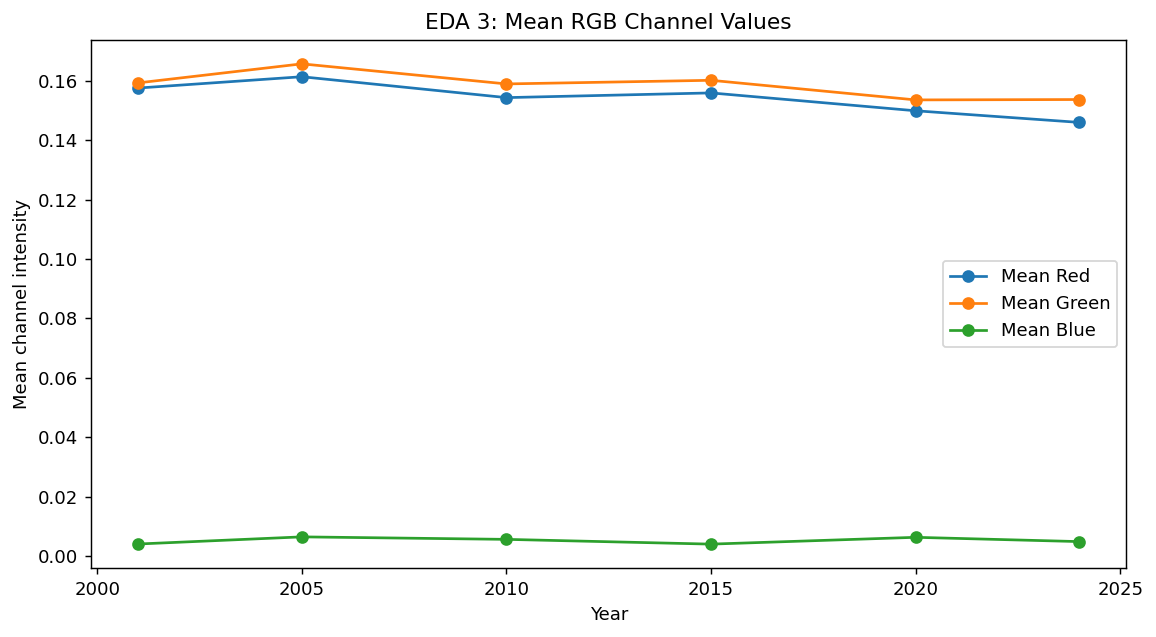

In [23]:
plt.figure(figsize=(9, 5))

plt.plot(metrics_df["year"], metrics_df["mean_red"], marker="o", label="Mean Red")
plt.plot(metrics_df["year"], metrics_df["mean_green"], marker="o", label="Mean Green")
plt.plot(metrics_df["year"], metrics_df["mean_blue"], marker="o", label="Mean Blue")

plt.title("EDA 3: Mean RGB Channel Values")
plt.xlabel("Year")
plt.ylabel("Mean channel intensity")
plt.legend()
plt.tight_layout()
plt.show()

## Graph 4 - Check the ratio of warmer pixels over time

Looks at how much of the image is visually brighter colored


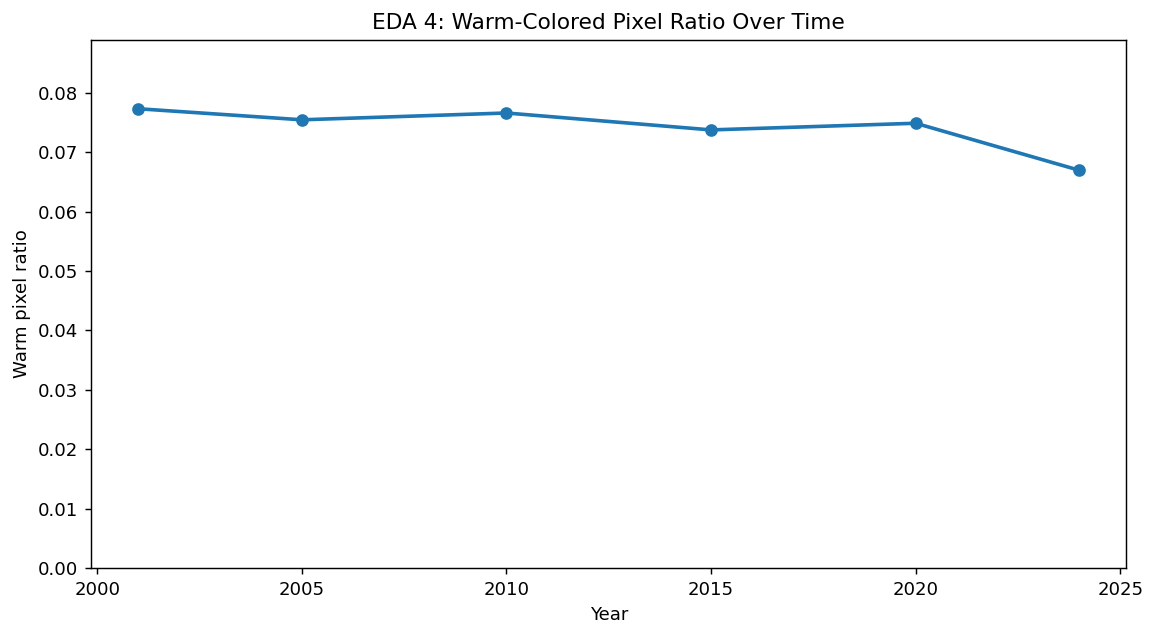

In [24]:
plt.figure(figsize=(9, 5))
plt.plot(metrics_df["year"], metrics_df["warm_pixel_ratio"], marker="o", linewidth=2)
plt.title("EDA 4: Warm-Colored Pixel Ratio Over Time")
plt.xlabel("Year")
plt.ylabel("Warm pixel ratio")
plt.ylim(0, max(metrics_df["warm_pixel_ratio"].max() * 1.15, 0.01))
plt.tight_layout()
plt.show()

## Graph 5 - RGB Pixel Difference Map

Shows image changed most strongly, helpful for pointing out specifc images on the final visual

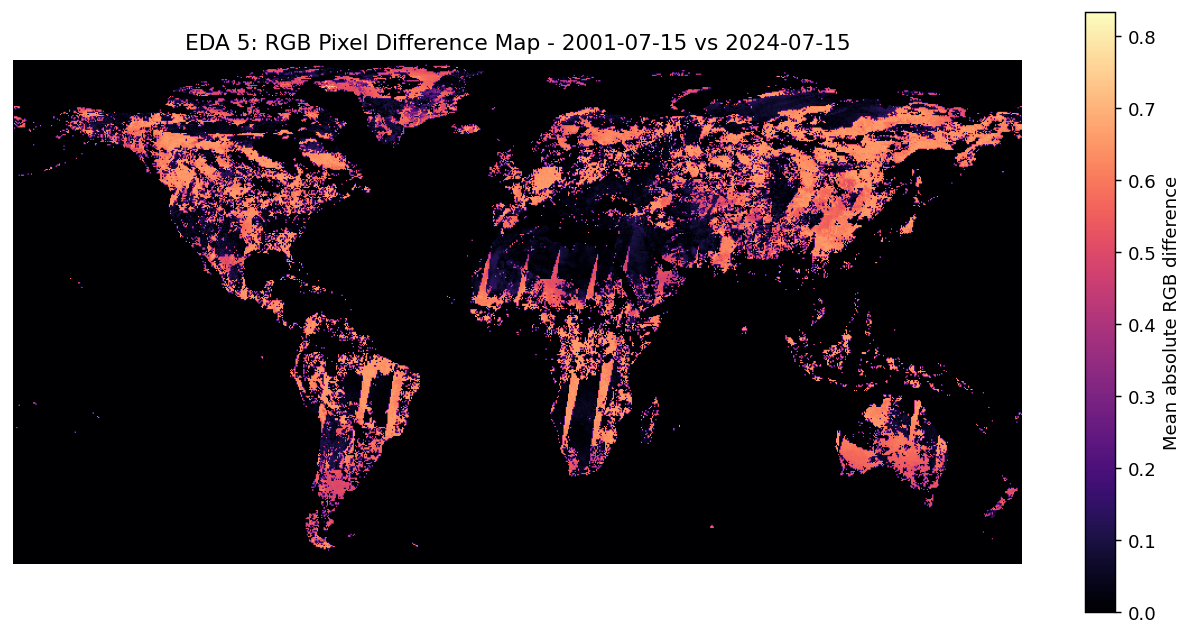

In [25]:
first_date = available_dates[0]
last_date = available_dates[-1]

arr_first = image_to_rgb_array(images[first_date])
arr_last = image_to_rgb_array(images[last_date])

diff = np.abs(arr_last - arr_first).mean(axis=2)

plt.figure(figsize=(10, 5))
plt.imshow(diff, cmap="magma")
plt.colorbar(label="Mean absolute RGB difference")
plt.axis("off")
plt.title(f"EDA 5: RGB Pixel Difference Map - {first_date} vs {last_date}")
plt.tight_layout()
plt.show()

## VERY! Basic template of how d3 visualisation would look like

Uses warmer pixel ratio from the graphs to build up basic idea of spiral from the images


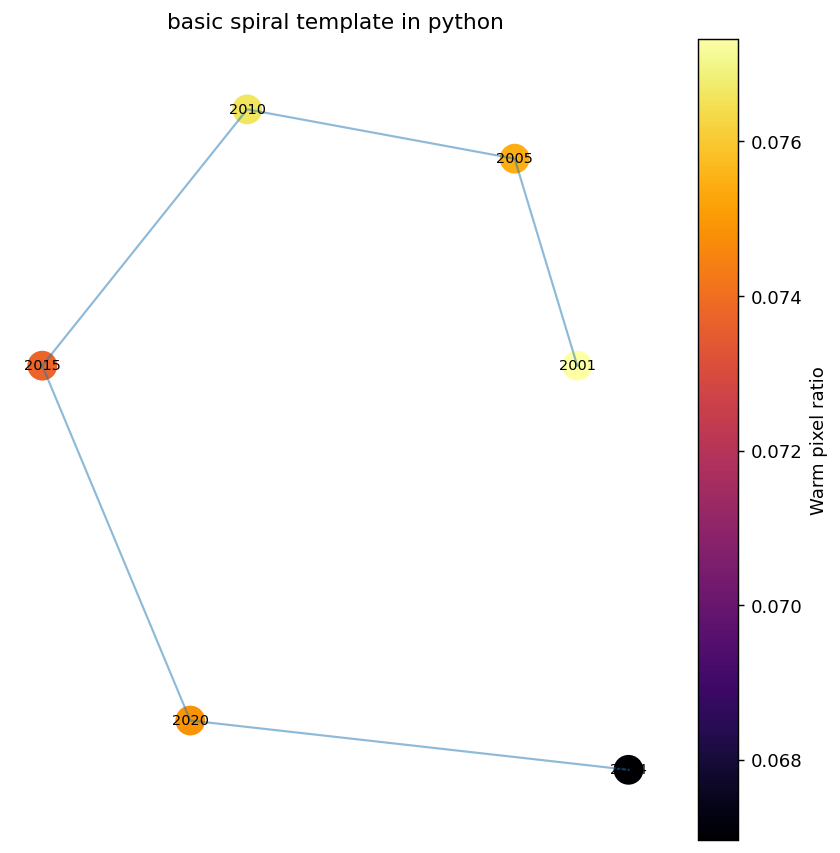

,date,year,mean_red,mean_green,mean_blue,brightness,warm_pixel_ratio,time_index,x,y
0,2001-07-15,2001,0.157520,0.159256,0.004146,0.106974,0.077321,0,0.800,0.000000e+00
1,2005-07-15,2005,0.161322,0.165655,0.006549,0.111175,0.075459,1,0.525,9.093267e-01
2,2010-07-15,2010,0.154296,0.158899,0.005708,0.106301,0.076605,2,-0.650,1.125833e+00
3,2015-07-15,2015,0.155877,0.160123,0.004107,0.106702,0.073758,3,-1.550,1.898203e-16
4,2020-07-15,2020,0.149870,0.153526,0.006399,0.103265,0.074879,4,-0.900,-1.558846e+00
5,2024-07-15,2024,0.145959,0.153652,0.004958,0.101523,0.066963,5,1.025,-1.775352e+00


In [27]:
spiral_df = metrics_df.copy().reset_index(drop=True)
spiral_df["time_index"] = np.arange(len(spiral_df))

theta = 2 * np.pi * spiral_df["time_index"] / max(len(spiral_df), 1)
radius = 0.8 + 0.25 * spiral_df["time_index"]

spiral_df["x"] = radius * np.cos(theta)
spiral_df["y"] = radius * np.sin(theta)

plt.figure(figsize=(8, 8))

sc = plt.scatter(
    spiral_df["x"],
    spiral_df["y"],
    c=spiral_df["warm_pixel_ratio"],
    s=240,
    cmap="inferno"
)

plt.plot(spiral_df["x"], spiral_df["y"], linewidth=1.2, alpha=0.5)

for _, row in spiral_df.iterrows():
    plt.text(row["x"], row["y"], str(int(row["year"])), ha="center", va="center", fontsize=8)

plt.colorbar(sc, label="Warm pixel ratio")
plt.title("basic spiral template in python")
plt.axis("equal")
plt.axis("off")
plt.show()

spiral_df